# EXERCISE 1:
##### AI disclaimer: Claude was used to generate the code for the plots. All analysis and write up, including customisation of the code was performed by me. 

In [36]:
# Cell 1: Importing the necessary packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [37]:
import pandas as pd

#loading in the csv file
flynn = pd.read_csv('/Users/victoriaseale/Library/CloudStorage/OneDrive-UniversityofCapeTown/Oceanography Honours/Mod7 - Marcello_2/flynn94.csv')

#previewing the data
flynn.head()

,time,cells,biovolume,ammonium,cellC,chl-a
0,0.0,0.04,2.0,1.411,0.60,4.0
1,0.5,0.04,2.2,1.400,0.61,3.0
2,1.0,0.04,2.1,1.383,0.58,3.0
3,1.5,0.04,2.1,1.355,NaN,3.0
4,2.0,0.04,2.1,1.355,0.68,3.0


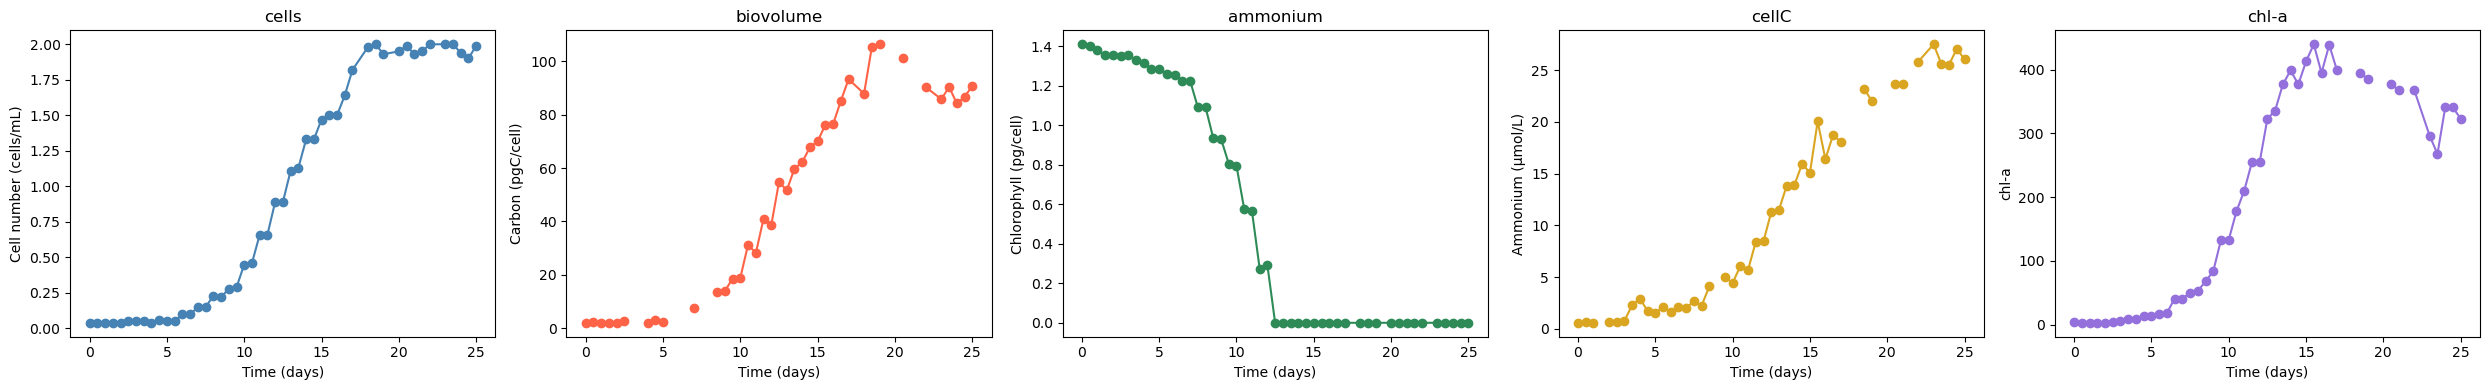

In [38]:

time_col = flynn.columns[0]
variables = flynn.columns[1:]

x_label = 'Time (days)'

y_labels = {
    variables[0]: 'Cell number (cells/mL)',
    variables[1]: 'Carbon (pgC/cell)',
    variables[2]: 'Chlorophyll (pg/cell)',
    variables[3]: 'Ammonium (µmol/L)',
}

colours = ['steelblue', 'tomato', 'seagreen', 'goldenrod', 'mediumpurple']
# ────────────────────────────────────────────────────────────

n = len(variables)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

for ax, col, colour in zip(axes, variables, colours):
    ax.plot(flynn[time_col], flynn[col], 'o-', color=colour)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_labels.get(col, col))
    ax.set_title(col)

plt.tight_layout()
plt.show()

### 1. Is the growth exponential?
Yes, cell number, cellular carbon both have a linear increase when plotted on a log scale, indicating exponential growth. When viewed as their grwoth rate over time, there is an exponential growth phase visible between days 5-17. 

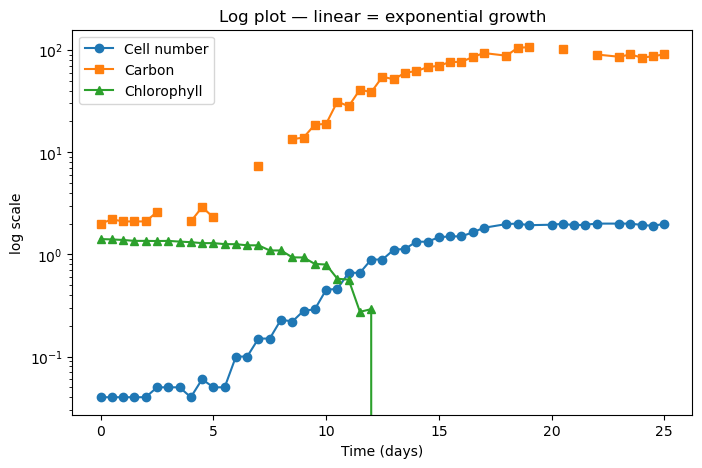

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(flynn[time_col], flynn[flynn.columns[1]], 'o-', label='Cell number')
ax.semilogy(flynn[time_col], flynn[flynn.columns[2]], 's-', label='Carbon')
ax.semilogy(flynn[time_col], flynn[flynn.columns[3]], '^-', label='Chlorophyll')
ax.set_xlabel('Time (days)')
ax.set_ylabel('log scale')
ax.set_title('Log plot — linear = exponential growth')
ax.legend()
plt.show()

### 2. Can you separate the growth curve into some phases?
Yes, there are three main growth phases. the Lag phase (days 1-5), the Exponential Growth phase (days 5-18) and the stationary phase (days 18-25). 

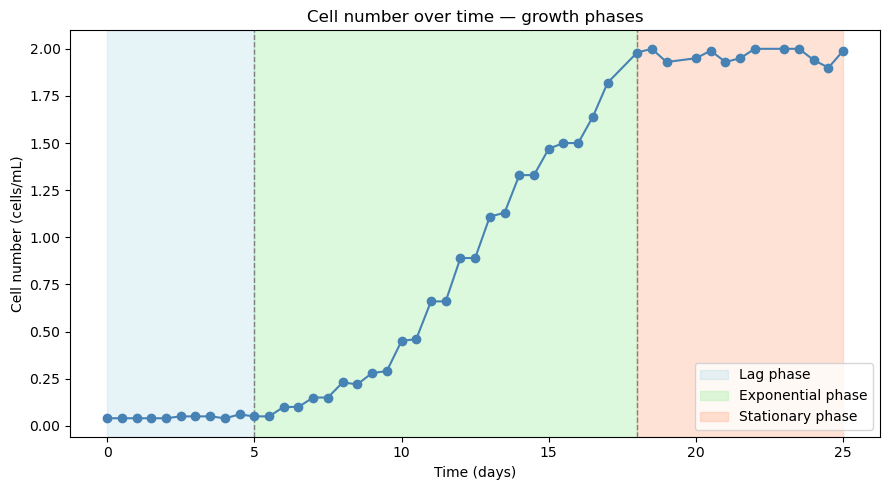

In [40]:
time_col = flynn.columns[0]
cell_col = flynn.columns[1]

phase_boundaries = [5, 18]  

phase_labels = ['Lag phase', 'Exponential phase', 'Stationary phase']
phase_colours = ['lightblue', 'lightgreen', 'lightsalmon']

fig, ax = plt.subplots(figsize=(9, 5))

# shade phases
boundaries = [flynn[time_col].min()] + phase_boundaries + [flynn[time_col].max()]
for i in range(len(boundaries) - 1):
    ax.axvspan(boundaries[i], boundaries[i+1],
               alpha=0.3, color=phase_colours[i], label=phase_labels[i])

# plot data on top
ax.plot(flynn[time_col], flynn[cell_col], 'o-', color='steelblue', zorder=3)

# vertical lines at boundaries
for b in phase_boundaries:
    ax.axvline(b, color='grey', linestyle='--', linewidth=1)

ax.set_xlabel('Time (days)')
ax.set_ylabel('Cell number (cells/mL)')
ax.set_title('Cell number over time — growth phases')
ax.legend()
plt.tight_layout()
plt.show()

### 3. How different is the growth expressed in cellular carbon from the one in cell number and chlorophyll?
Cell number and Cellular carbon are relatively similar in growth rate, where as Chlorophyll reaches a maximum more quickly and then starts to decrease. 

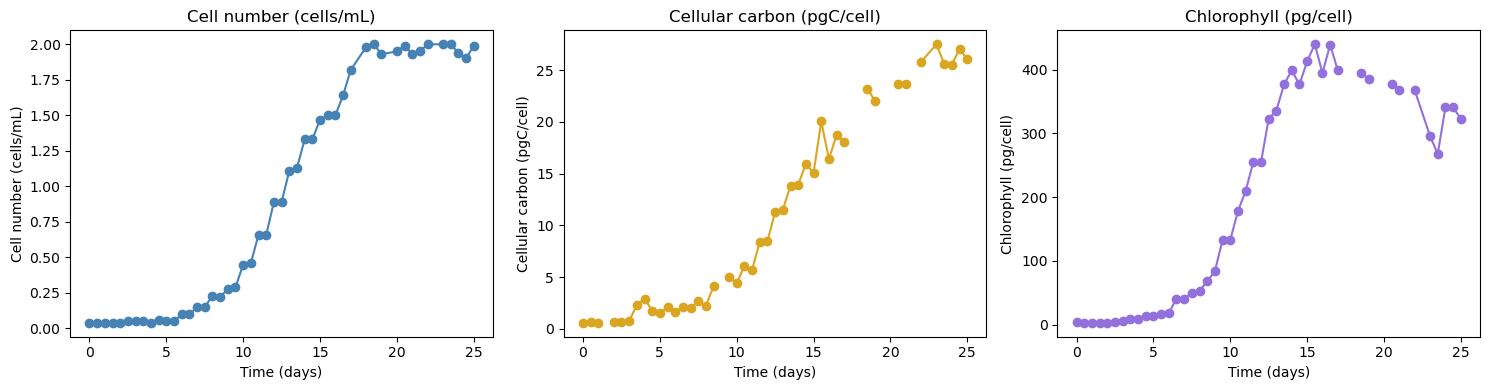

In [41]:
time_col = flynn.columns[0]

x_label = 'Time (days)'

plots = [
    {'col': flynn.columns[1], 'label': 'Cell number (cells/mL)',  'colour': 'steelblue'},
    {'col': flynn.columns[4], 'label': 'Cellular carbon (pgC/cell)', 'colour': 'goldenrod'},
    {'col': flynn.columns[5], 'label': 'Chlorophyll (pg/cell)',    'colour': 'mediumpurple'},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, p in zip(axes, plots):
    ax.plot(flynn[time_col], flynn[p['col']], 'o-', color=p['colour'])
    ax.set_xlabel(x_label)
    ax.set_ylabel(p['label'])
    ax.set_title(p['label'])

plt.tight_layout()
plt.show()

### 4. Is the ammonium consumption approximated by an exponential curve?
The shape of the graph with an inverted y axis represents an exponential graph. The actual ammonium concentration over time graph is showing decay. The ammonium decreases exponentially over time. 

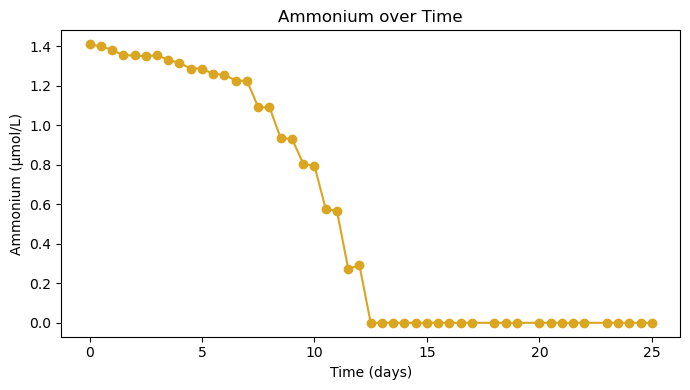

In [42]:
time_col = flynn.columns[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(flynn[time_col], flynn[flynn.columns[3]], 'o-', color='goldenrod')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Ammonium (µmol/L)')
ax.set_title('Ammonium over Time')
plt.tight_layout()
plt.show()

#### 5. How would you estimate the parameters of the growth curve?
The growth curve is based on the exponential population growth equation.

$$N(t) = N_0 \cdot e^{\mu t}$$

Where:
- $N(t)$ = cell number at time $t$
- $N_0$ = initial cell number at $t = 0$
- $\mu$ = specific growth rate (day$^{-1}$)
- $t$ = time (days)

Doubling time:

$$t_{double} = \frac{\ln(2)}{\mu}$$

 The initial cell number, needs to be the initial cell number at the start of 5 days, this is when exponential growth starts. 

# Exercise 2:


$$\frac{dP}{dt} = k' N P$$

$$\frac{dN}{dt} = -k' N P$$

Where:
- $P$ = phytoplankton concentration (mmol N m$^{-3}$)
- $N$ = nutrient concentration (mmol N m$^{-3}$)
- $k'$ = uptake rate (d$^{-1}$)
- $t$ = time (days)

**Conservation law:** $N(t) + P(t) = S = N_0 + P_0$ (constant)

The equation describes the logistic growth model, when the growth is limited by the resource. In this case, the phytoplankton grwoth is limited by the amount of nutrients available to them. 

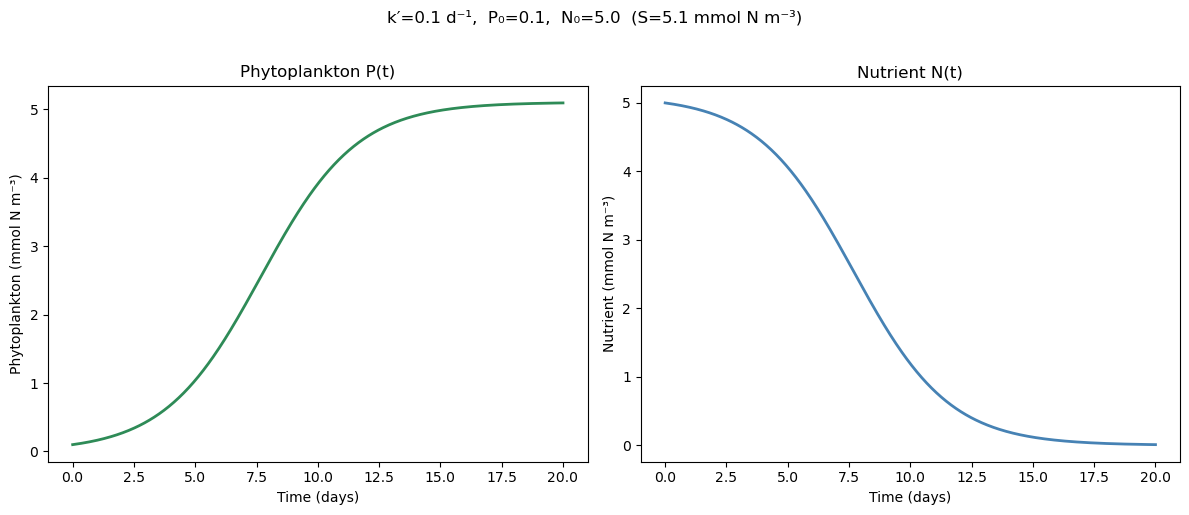

In [47]:
# Plot P(t) and N(t)
# Parameters:
k_prime = 0.1          # uptake rate (d⁻¹)
P0      = 0.1          # initial phytoplankton (mmol N m⁻³)
N0      = 5.0          # initial nutrient (mmol N m⁻³)

#parameters classified using the analytical solution:
t = np.linspace(0, 20, 500)   # time axis (days)
S = N0 + P0   # total nitrogen (conserved)

exp_term = np.exp(k_prime * S * t)
P = (S * P0 * exp_term) / (S + P0 * (exp_term - 1))
N = S - P

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, P, color='seagreen', linewidth=2)
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Phytoplankton (mmol N m⁻³)')
axes[0].set_title('Phytoplankton P(t)')

axes[1].plot(t, N, color='steelblue', linewidth=2)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Nutrient (mmol N m⁻³)')
axes[1].set_title('Nutrient N(t)')

plt.suptitle(f"k′={k_prime} d⁻¹,  P₀={P0},  N₀={N0}  (S={S} mmol N m⁻³)", y=1.02)
plt.tight_layout()
plt.show()

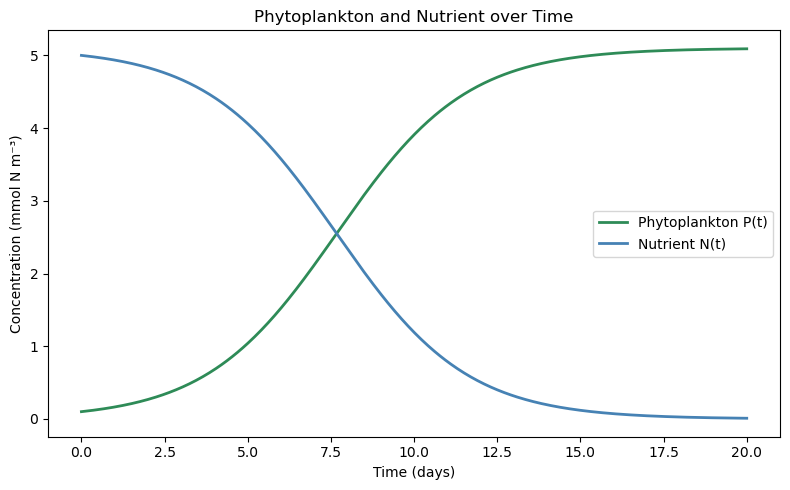

In [48]:
# Overlay both on one plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, P, color='seagreen', linewidth=2, label='Phytoplankton P(t)')
ax.plot(t, N, color='steelblue', linewidth=2, label='Nutrient N(t)')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Concentration (mmol N m⁻³)')
ax.set_title('Phytoplankton and Nutrient over Time')
ax.legend()
plt.tight_layout()
plt.show()

### 1. Why are the curves identical in shape? 
This model is governed by the Law of Conservation of Mass. The amount of nutrients is conserved in this system as well as the mass of the phytoplankton, it assumes every unit gained by the phytoplankton is equally lost by the nutrients. This creates lines of mirror images. 

The 5.1 is the conserved quantity, it is the sum of the inital P added to the initial N.

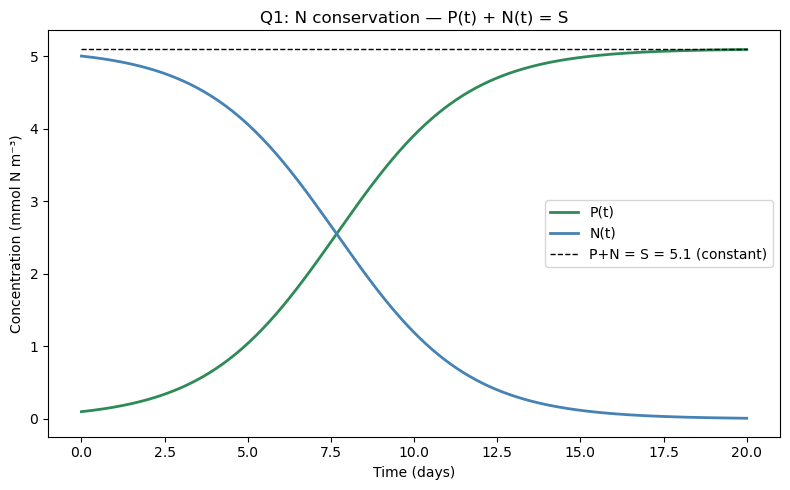

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, P, color='seagreen', linewidth=2, label='P(t)')
ax.plot(t, N, color='steelblue', linewidth=2, label='N(t)')
ax.plot(t, P + N, 'k--', linewidth=1, label=f'P+N = S = {S} (constant)')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Concentration (mmol N m⁻³)')
ax.set_title('Q1: N conservation — P(t) + N(t) = S')
ax.legend()
plt.tight_layout()
plt.show()

### 2. What happens when you change the value of the uptake parameter. Think about it as the percentage of food consumed per day.
A higher value of K, equates to faster consumption and higher of nutrients per day by the phytoplankton. This visually appears as a steeper curve with earlier saturation. The phytoplankton will reach a maximum more quickly with a higher value of K, and the nutrients will reach a minimum at the same time, but also at a faster rate than a smaller K value. 


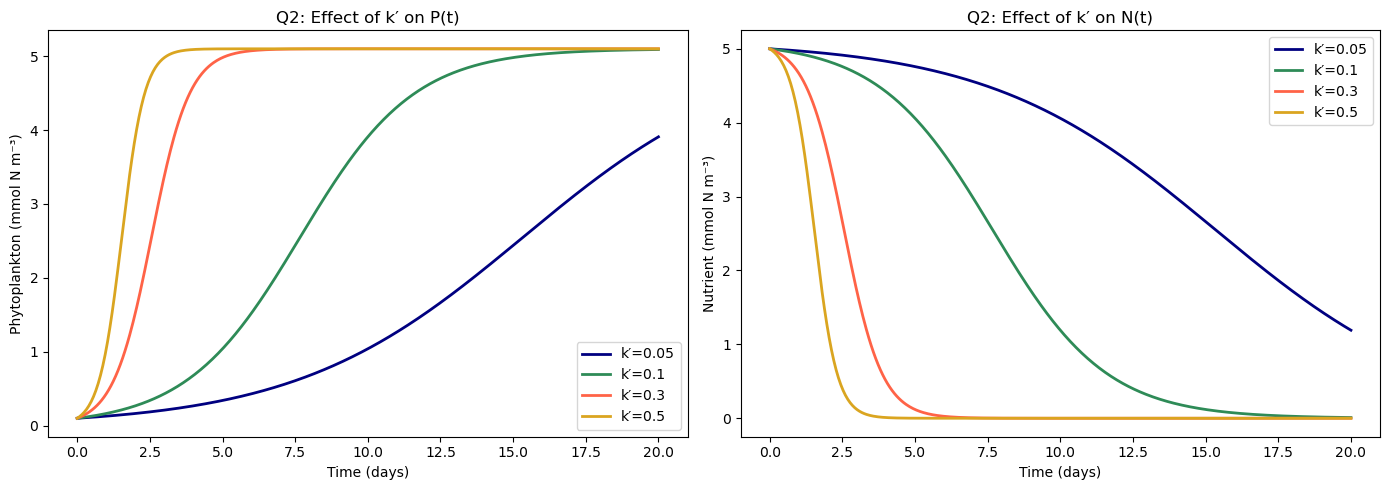

In [50]:
k_values  = [0.05, 0.1, 0.3, 0.5]
colours   = ['navy', 'seagreen', 'tomato', 'goldenrod']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k, c in zip(k_values, colours):
    exp_term = np.exp(k * S * t)
    P_k = (S * P0 * exp_term) / (S + P0 * (exp_term - 1))
    N_k = S - P_k
    axes[0].plot(t, P_k, color=c, linewidth=2, label=f"k′={k}")
    axes[1].plot(t, N_k, color=c, linewidth=2, label=f"k′={k}")

for ax, title, ylabel in zip(axes,
                              ['Q2: Effect of k′ on P(t)', 'Q2: Effect of k′ on N(t)'],
                              ['Phytoplankton (mmol N m⁻³)', 'Nutrient (mmol N m⁻³)']):
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### 3. What happens if the initial biomass of phytoplankton is close to the amount of resource available? How does the shape of the curve change?
As the amount of phytoplankton are increased as an initial condition, the shape of the s-shape curve flattens more quickly, their exponential growth stage is much quicker and short-lived. There is a less pronounced exponential phase because the nutrients are already limiting from the start. 
This is due to the law of conservation of mass, which states if there is an increase in biomass (phytoplankton), there will be a rapid decrease in the nutrients. 
With each varying initial biomass concentration, there is a new equilibrium value that is established. With a higher biomass initial value, the nutrients are depleted much more quickly. 

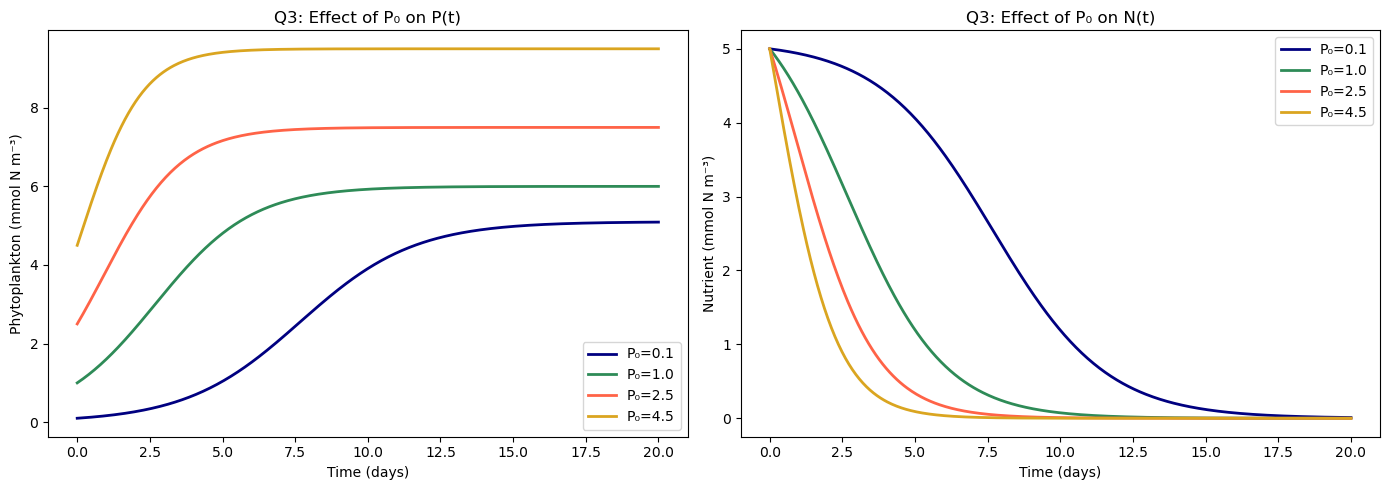

In [51]:
P0_values = [0.1, 1.0, 2.5, 4.5]
colours   = ['navy', 'seagreen', 'tomato', 'goldenrod']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for P0_i, c in zip(P0_values, colours):
    S_i = N0 + P0_i
    exp_term = np.exp(k_prime * S_i * t)
    P_i = (S_i * P0_i * exp_term) / (S_i + P0_i * (exp_term - 1))
    N_i = S_i - P_i
    axes[0].plot(t, P_i, color=c, linewidth=2, label=f"P₀={P0_i}")
    axes[1].plot(t, N_i, color=c, linewidth=2, label=f"P₀={P0_i}")

for ax, title, ylabel in zip(axes,
                              ['Q3: Effect of P₀ on P(t)', 'Q3: Effect of P₀ on N(t)'],
                              ['Phytoplankton (mmol N m⁻³)', 'Nutrient (mmol N m⁻³)']):
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

# Exercise 3: